In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report
)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving framingham.csv to framingham.csv


In [ ]:
import pandas as pd

df = pd.read_csv("framingham.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [ ]:
#df.head()
#df.tail()
#df.shape
#df.columns
#df.info()
#df.describe()

In [ ]:
df.isnull().sum()

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


In [ ]:
df.duplicated().sum()

np.int64(0)

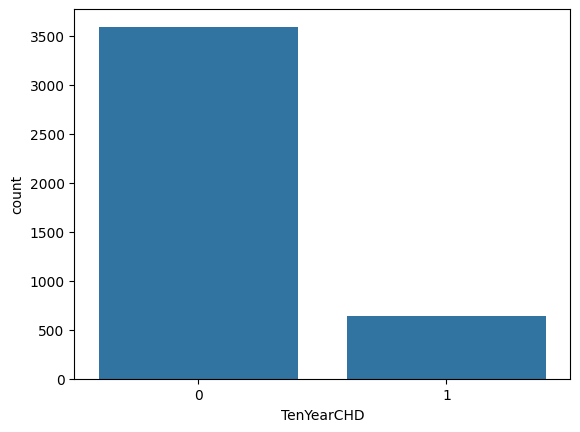

In [ ]:
df['TenYearCHD'].value_counts()

sns.countplot(x='TenYearCHD', data=df)
plt.show()

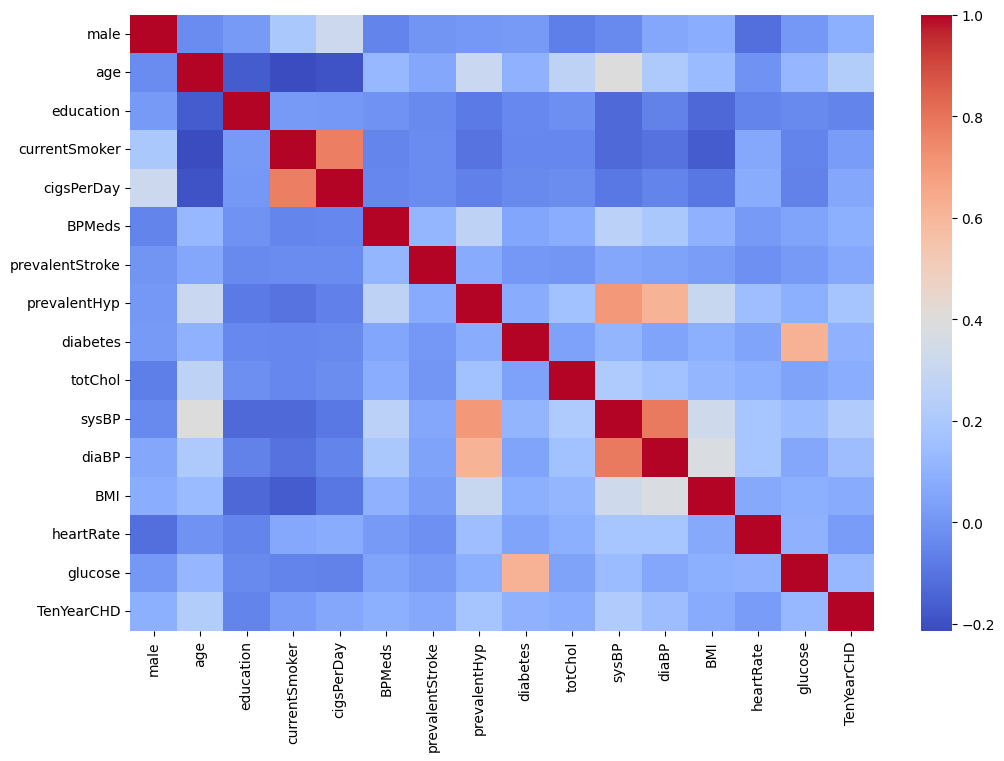

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [ ]:
df.fillna(df.median(), inplace=True)

In [ ]:
df.isnull().sum()

,0
male,0
age,0
education,0
currentSmoker,0
cigsPerDay,0
BPMeds,0
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,0


In [ ]:
y = df['TenYearCHD']
X = df.drop('TenYearCHD', axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [ ]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1:", f1_score(y_test, lr_pred))

Accuracy: 0.8549528301886793
Precision: 0.5
Recall: 0.06504065040650407
F1: 0.11510791366906475


In [ ]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))

Accuracy: 0.8549528301886793
Precision: 0.5
Recall: 0.04065040650406504
F1: 0.07518796992481203


Interpretation
-Both models have the same accuracy (85.5%), but this is misleading because most patients do not have heart disease.
-Both models have 50% precision, meaning half of the patients predicted to have heart disease actually did.
-Logistic Regression is better because it has higher recall (6.5% vs. 4.1%), so it detects more heart disease cases.
-oth models have very low F1 scores, indicating poor overall performance in identifying positive cases.
-Neither model is suitable for clinical use in its current form because they miss most patients with heart disease.

| Metric    | Logistic Regression | Random Forest | Better Model        |
| --------- | ------------------- | ------------- | ------------------- |
| Accuracy  | **85.5%**           | **85.5%**     | Tie                 |
| Precision | **50%**             | **50%**       | Tie                 |
| Recall    | **6.5%**            | **4.1%**      | Logistic Regression |
| F1 Score  | **11.5%**           | **7.5%**      | Logistic Regression |


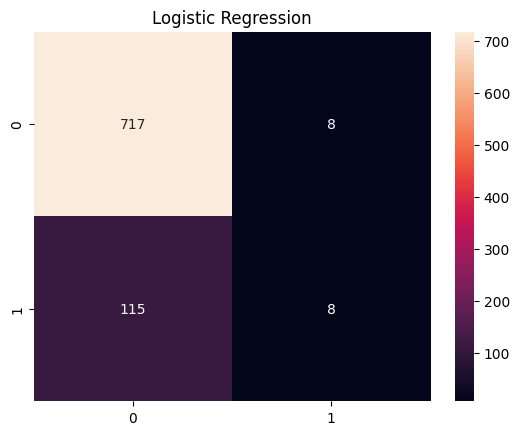

In [ ]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression")
plt.show()

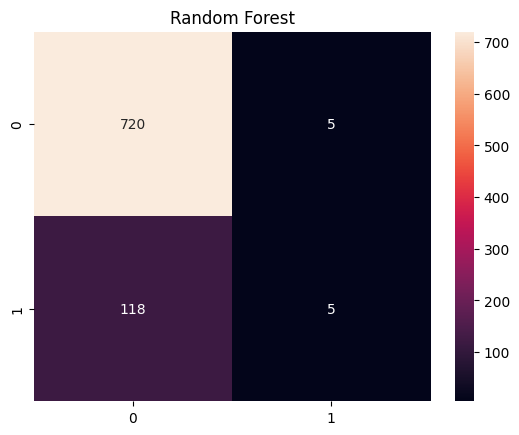

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest")
plt.show()

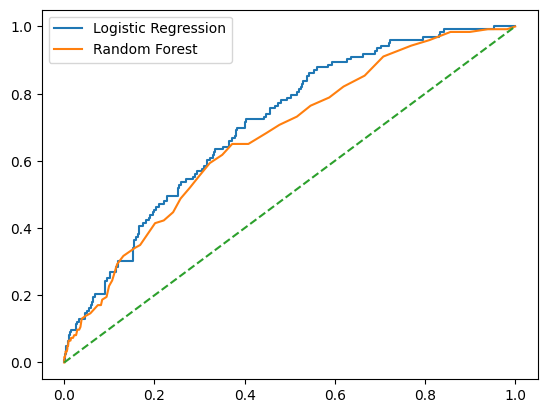

In [ ]:
lr_prob = lr.predict_proba(X_test_scaled)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.plot(lr_fpr, lr_tpr, label='Logistic Regression')
plt.plot(rf_fpr, rf_tpr, label='Random Forest')
plt.plot([0,1],[0,1],'--')

plt.legend()
plt.show()

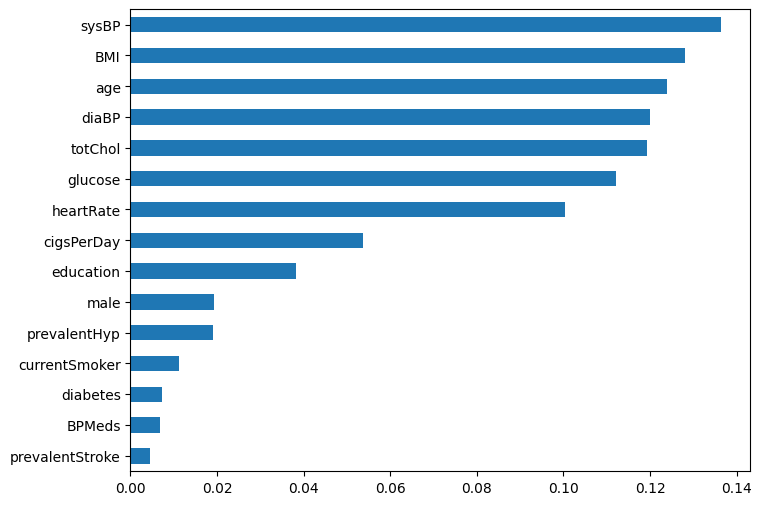

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.show()